In [28]:
#Importing numpy, pandas, seaborn, matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importing TensorFlow for Deep Learning related work
import tensorflow as tf
from tensorflow import keras

In [29]:
#Loading the Fashion-MNIST Dataset
try:
   (xtr,ytr),(xte,yte) = keras.datasets.fashion_mnist.load_data()
   using_mnist = True
   print(f"Training images: {xtr.shape}")
   print(f"Test images: {xte.shape}")
   print(f"Labels: Fashion Types {np.unique(ytr)}")
except Exception:
   print("----In google Colab, the full MNIST loads automatically.----")
   from sklearn.datasets import load_digits
   from sklearn.model_selection import train_test_split as tts
   fashion = load_digits()
   img = fashion.images

   xd = img.astype("float32")
   yd = fashion.target
   xtr, xte, ytr, yte = tts(xd, yd, test_size=0.2, random_state=42)
   using_mnist = False
   print(f"Training images: {xtr.shape}")
   print(f"Test images: {xte.shape}")
   print(f"Labels: Fashion Types {np.unique(ytr)}")

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Labels: Fashion Types [0 1 2 3 4 5 6 7 8 9]


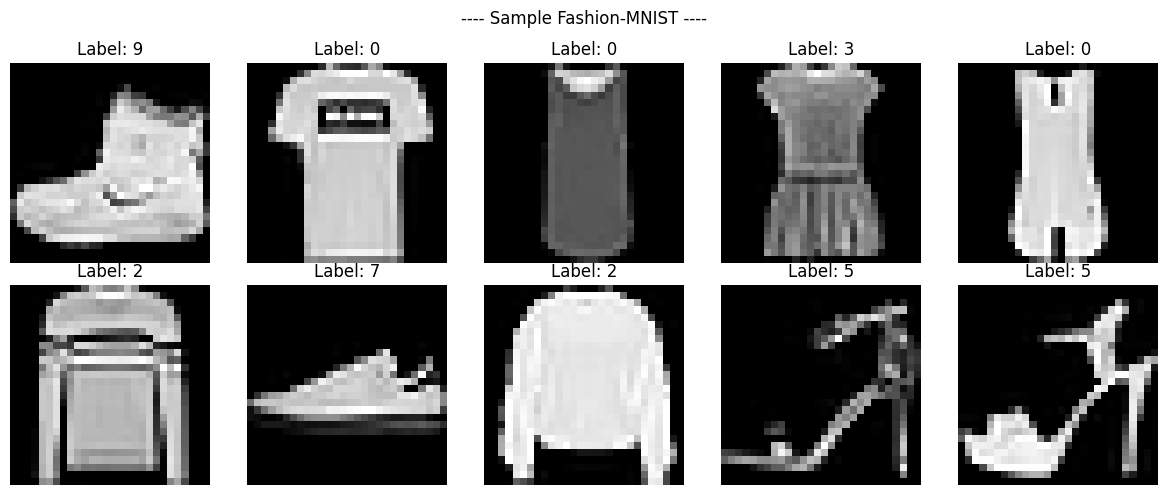

In [30]:
#Looking at sample images and their labels
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, a in enumerate(axes.flatten()):
  a.imshow(xtr[i], cmap="gray")
  a.set_title(f"Label: {ytr[i]}")
  a.axis("off")
plt.suptitle("---- Sample Fashion-MNIST ----")
plt.tight_layout()
plt.show()

In [31]:
#Normalizing and Flattening the pixels
npixels = xtr.shape[1] * xtr.shape[2]
pixel_max = xtr.max()

xtr_nor = xtr.reshape(-1, npixels) / pixel_max
xte_nor = xte.reshape(-1, npixels) / pixel_max

print(f"Pixel value before: 0 to {pixel_max:.0f}")
print(f"Pixel value after: 0.0 to {xtr_nor.max():.1f}")
print(f"Shape after flattening: {xtr_nor.shape} ({npixels} pixels per image)")

Pixel value before: 0 to 255
Pixel value after: 0.0 to 1.0
Shape after flattening: (60000, 784) (784 pixels per image)


In [32]:
#Building a neural network
#With 3 hidden layers
model = keras.Sequential([
    keras.layers.Input(shape=(npixels,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
#Training
#10 epochs
hist = model.fit(
    xtr_nor, ytr,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7778 - loss: 0.6232 - val_accuracy: 0.8398 - val_loss: 0.4309
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8477 - loss: 0.4197 - val_accuracy: 0.8562 - val_loss: 0.3846
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8622 - loss: 0.3791 - val_accuracy: 0.8618 - val_loss: 0.3790
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8701 - loss: 0.3559 - val_accuracy: 0.8740 - val_loss: 0.3501
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8742 - loss: 0.3403 - val_accuracy: 0.8780 - val_loss: 0.3334
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8806 - loss: 0.3254 - val_accuracy: 0.8710 - val_loss: 0.3462
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8826 - loss: 0.3164 - val_accuracy: 0.8827 - val_loss: 0.3229
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8865 - loss: 0.3041 - val_accuracy: 0.

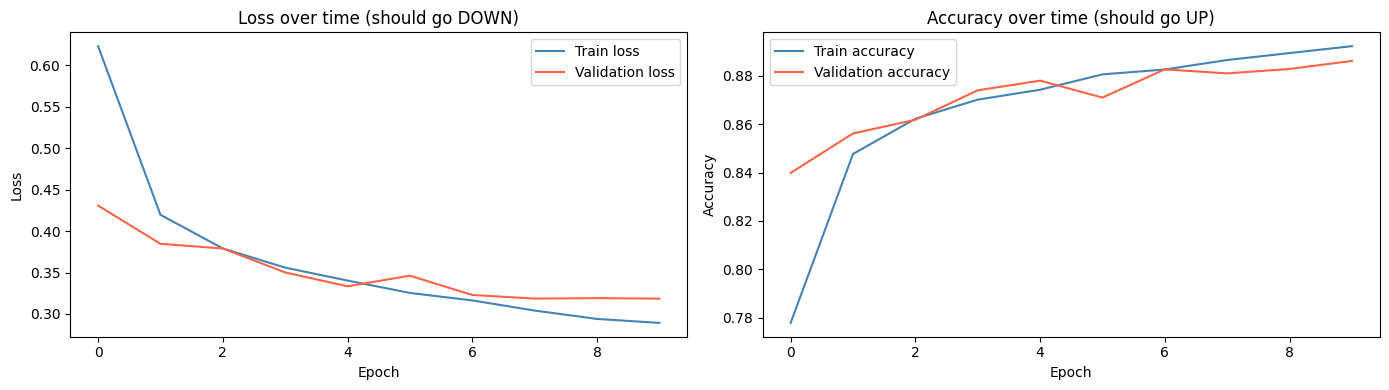

In [34]:
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(hist.history["loss"], label="Train loss", color="steelblue")
axes[0].plot(hist.history["val_loss"], label="Validation loss", color="tomato")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over time (should go DOWN)")
axes[0].legend()

# Accuracy
axes[1].plot(hist.history["accuracy"], label="Train accuracy", color="steelblue")
axes[1].plot(hist.history["val_accuracy"], label="Validation accuracy", color="tomato")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over time (should go UP)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
from tensorflow import keras
#Loading actual fashion mnist dataset
(xtr, ytr), (xte, yte) = keras.datasets.fashion_mnist.load_data()
#Normalizing the pixel values
xtr = xtr / 255.0
xte = xte / 255.0

print("xtr shape:", xtr.shape)
print("ytr shape:", ytr.shape)

xtr shape: (60000, 28, 28)
ytr shape: (60000,)


In [36]:
#Adding Dropout and comparing

from tensorflow import keras
from keras.callbacks import EarlyStopping

# Building model with dropout
model_dropout = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax")
])
model_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

# Early stopping — stop when validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
    )

hist2 = model_dropout.fit(
    xtr, ytr,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f"Training stopped at epoch {len(hist2.history['loss'])} (early stopping)")
print(f"Test accuracy: {model_dropout.evaluate(xte, yte, verbose=0)[1]*100:.1f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6055 - loss: 1.1162 - val_accuracy: 0.7973 - val_loss: 0.5612
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7494 - loss: 0.6986 - val_accuracy: 0.8300 - val_loss: 0.4785
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7790 - loss: 0.6202 - val_accuracy: 0.8410 - val_loss: 0.4430
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7961 - loss: 0.5783 - val_accuracy: 0.8448 - val_loss: 0.4306
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8050 - loss: 0.5522 - val_accuracy: 0.8518 - val_loss: 0.4142
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8120 - loss: 0.5350 - val_accuracy: 0.8512 - val_loss: 0.4098
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8157 - loss: 0.5213 - val_accuracy: 0.8582 - val_loss: 0.3963
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8201 - loss: 0.5091 - val_accuracy: 0.

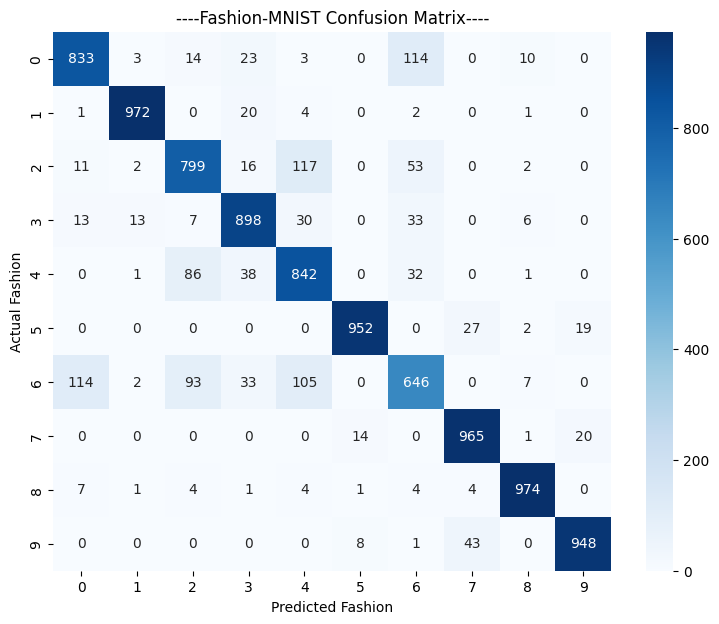

→ The diagonal is bright = most predictions are correct!


In [38]:
#Showing Confusion Matrix
from sklearn.metrics import confusion_matrix

all = np.argmax(model.predict(xte_nor, verbose=0), axis=1)
cm = confusion_matrix(yte, all)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted Fashion")
plt.ylabel("Actual Fashion")
plt.title("----Fashion-MNIST Confusion Matrix----")
plt.show()
print("→ The diagonal is bright = most predictions are correct!")

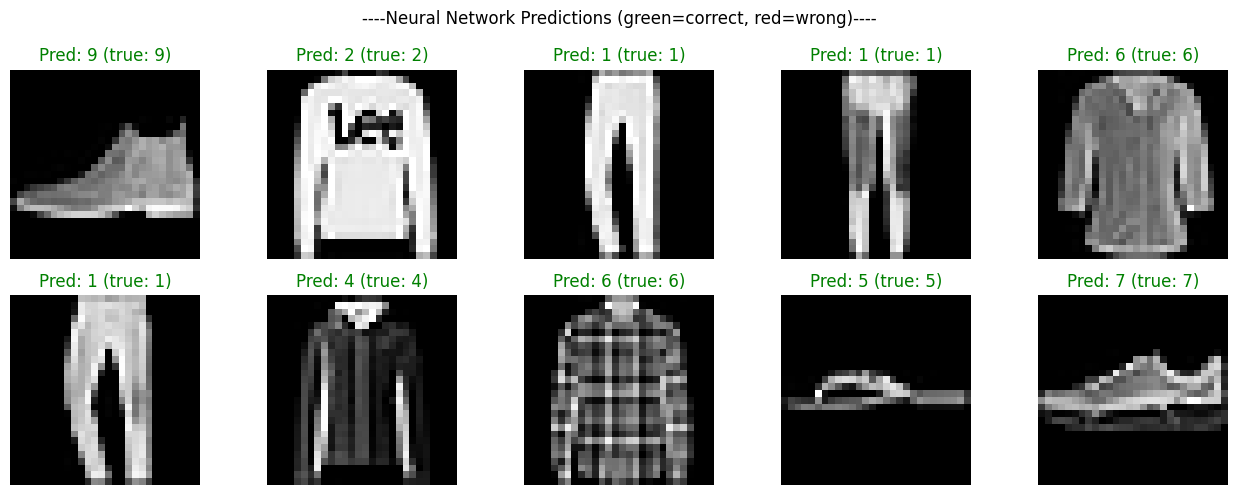

In [39]:
#Making predictions

predictions = model.predict(xte_nor[:10], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, a in enumerate(axes.flatten()):
    a.imshow(xte[i], cmap="gray")
    correct = predicted_labels[i] == yte[i]
    color = "green" if correct else "red"
    a.set_title(f"Pred: {predicted_labels[i]} (true: {yte[i]})", color=color)
    a.axis("off")
plt.suptitle("----Neural Network Predictions (green=correct, red=wrong)----")
plt.tight_layout()
plt.show()